In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import talib as ta

from utilities_notebook import check_stationarity

In [2]:
data = pd.read_csv("data/data.csv", index_col=0, parse_dates=True)
data.head()

,close,high,low,volume
Date,,,,
2023-01-03,1.843226,1.861659,1.824794,1624100
2023-01-04,1.834010,1.880091,1.834010,1706800
2023-01-05,1.834010,1.843226,1.824794,1391300
2023-01-06,1.880091,1.880091,1.834010,3364000
2023-01-09,1.898523,1.898523,1.880091,3771500


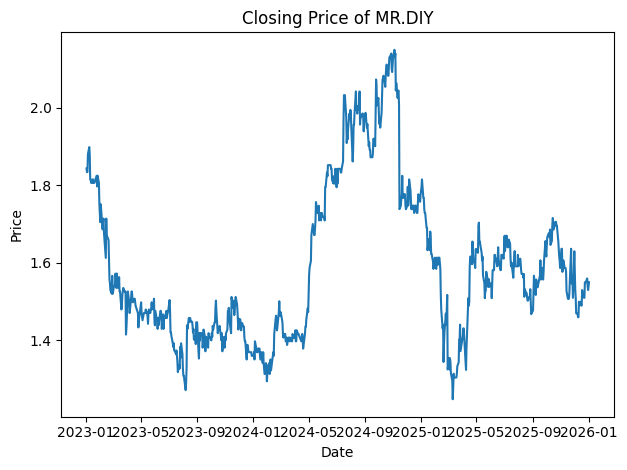

In [3]:
fig, ax = plt.subplots(1, 1)

ax.plot(data['close'])
ax.set_title("Closing Price of MR.DIY")
ax.set_ylabel("Price")
ax.set_xlabel(data.index.name)

plt.tight_layout()
plt.show()

Feature Engineering

In [4]:
# 'future_1d_return', 'signal' for buy or sell
data['future_1d_return'] = data['close'].pct_change().shift(-1)
data['signal'] = np.where(data['future_1d_return'] > 0, 1, 0)

# pct_change_1d, pct_change_5d, rsi, adx, volatility

data['pct_change_1d'] = data['close'].pct_change()
data['pct_change_5d'] = data['close'].pct_change(5)

p = 10 # period of last two weeks: 10. 1 week has 10 trading days
data['rsi'] = ta.RSI(data['close'], timeperiod=p)
data['adx'] = ta.ADX(data['high'], data['low'], data['close'], timeperiod=p)

data['sma'] = data['close'].rolling(window=p).mean()
data['corr'] = data['close'].rolling(window=p).corr(data['sma'])

data['volatility'] = data['pct_change_1d'].rolling(window=p, min_periods=p).std() * 100

print(data.head())
print(f"\nLength of future_1d_return: {len(data['future_1d_return'])}, \
      Length of 1's (buy signals): {len(data[data['signal'] == 1])}")

print(f"Length of data: {data.shape}")
data.dropna(inplace=True)
print(f"Length of data after dropping NaN values: {data.shape}")

               close      high       low   volume  future_1d_return  signal  \
Date                                                                          
2023-01-03  1.843226  1.861659  1.824794  1624100         -0.005000       0   
2023-01-04  1.834010  1.880091  1.834010  1706800          0.000000       0   
2023-01-05  1.834010  1.843226  1.824794  1391300          0.025126       1   
2023-01-06  1.880091  1.880091  1.834010  3364000          0.009804       1   
2023-01-09  1.898523  1.898523  1.880091  3771500         -0.009709       0   

            pct_change_1d  pct_change_5d  rsi  adx  sma  corr  volatility  
Date                                                                       
2023-01-03            NaN            NaN  NaN  NaN  NaN   NaN         NaN  
2023-01-04      -0.005000            NaN  NaN  NaN  NaN   NaN         NaN  
2023-01-05       0.000000            NaN  NaN  NaN  NaN   NaN         NaN  
2023-01-06       0.025126            NaN  NaN  NaN  NaN   NaN     

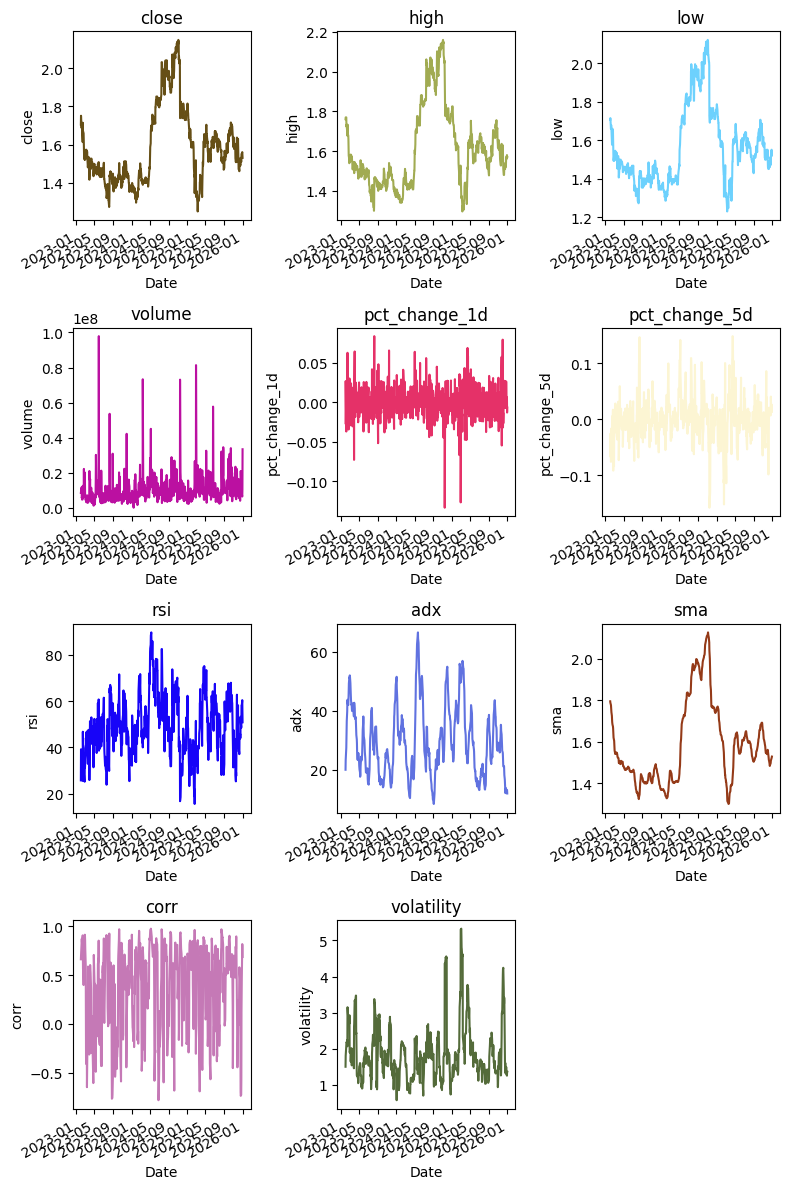

In [5]:
features = ['close', 'high', 'low', 'volume', 'pct_change_1d', 'pct_change_5d',
            'rsi', 'adx', 'sma', 'corr', 'volatility']
target = 'signal'

X = data[features].copy()

y = data[target].copy()

ncolumns = 3
nrows = (X.shape[1] + ncolumns-1) // ncolumns

i=1
for feature in X.columns:
    plt.subplot(nrows, ncolumns, i)

    X[feature].plot(figsize=(8, 12),color=np.random.rand(3))
    plt.ylabel(feature)
    plt.title(feature)
    i += 1

plt.tight_layout()
plt.show()

In [6]:
# Check features for stationarity and drop non-stationary features

ls = []
for column in X.columns:
    if check_stationarity(X[column]) == "non-stationary":
        ls.append(column)
        X.drop(columns=[column], inplace=True)
    print()

print(f"Dropped features: {ls}")

ADF Statistic: -2.0026835360436404
p-value: 0.28539770315833046
close is non-stationary. Failed to reject null hypothesis

ADF Statistic: -1.8322076877955877
p-value: 0.3645927279445931
high is non-stationary. Failed to reject null hypothesis

ADF Statistic: -1.9602769447674027
p-value: 0.3042571332790196
low is non-stationary. Failed to reject null hypothesis

ADF Statistic: -7.933609505603054
p-value: 3.4603143993301803e-12
volume is stationary. Null hypothesis rejected

ADF Statistic: -30.10924968601948
p-value: 0.0
pct_change_1d is stationary. Null hypothesis rejected

ADF Statistic: -4.785468498251615
p-value: 5.79760882645376e-05
pct_change_5d is stationary. Null hypothesis rejected

ADF Statistic: -5.633132133520891
p-value: 1.0780645032171144e-06
rsi is stationary. Null hypothesis rejected

ADF Statistic: -4.847685814623384
p-value: 4.404337886583477e-05
adx is stationary. Null hypothesis rejected

ADF Statistic: -1.503153127350024
p-value: 0.5319509592087918
sma is non-station

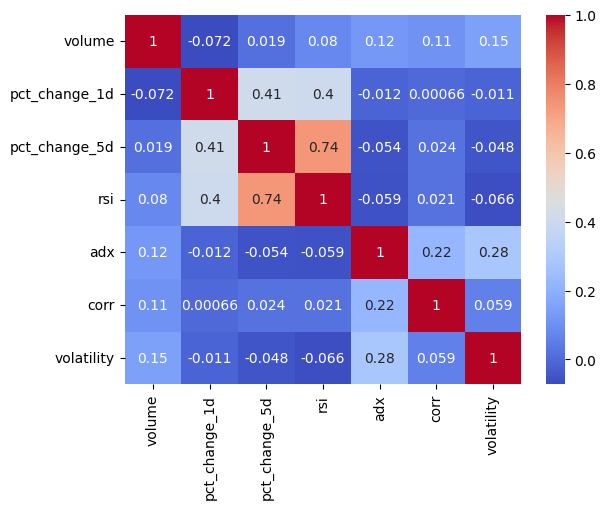

In [7]:
import seaborn as sns

plt.figure()
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.show()

In [8]:
# Drop 'pct_change_5d' due to correlation of 0.74 with rsi
X.drop(columns=['pct_change_5d'], inplace=True)

In [9]:
# Final features

list(X.columns)

['volume', 'pct_change_1d', 'rsi', 'adx', 'corr', 'volatility']

In [10]:
# Add closing price to features for strategy evaluation later
X = pd.concat([data['close'].copy(), X], axis=1)
X.head()

,close,volume,pct_change_1d,rsi,adx,corr,volatility
Date,,,,,,,
2023-02-02,1.704984,8523200,-0.026316,25.717409,20.038163,0.662247,1.503281
2023-02-03,1.751065,9219400,0.027027,39.158280,23.303452,0.701774,1.806856
2023-02-07,1.686552,11662300,-0.036842,30.557384,27.484320,0.837257,2.094658
2023-02-08,1.704984,5665300,0.010929,35.083919,31.247101,0.872249,2.160629
2023-02-09,1.714200,6074700,0.005405,37.352556,33.787339,0.837857,2.182699


Feature engineering for polynomial features of degree 2

In [11]:
squared_terms = (X.drop(columns=['close']) ** 2).rename(columns={'volume':'volume^2', 'pct_change_1d':'pct_change_1d^2', 'rsi':'rsi^2',
                                       'adx':'adx^2', 'corr':'corr^2', 'volatility':'volatility^2'})

interaction_terms = pd.DataFrame(index=X.index)

cols_int_terms = [
    'volume*pct_change_1d', 'volume*rsi', 'volume*adx', 'volume*corr', 'volume*volatility',
    'pct_change_1d*rsi', 'pct_change_1d*adx', 'pct_change_1d*corr', 'pct_change_1d*volatility',
    'rsi*adx', 'rsi*corr', 'rsi*volatility', 'adx*corr', 'adx*volatility', 'corr*volatility'
]

for term in cols_int_terms:
    # Split the string by '*' to get the two feature names
    feat_a, feat_b = term.split('*')
    interaction_terms[term] = X[feat_a] * X[feat_b]

X_poly = pd.concat([X, squared_terms, interaction_terms], axis=1)

features2 = ['volume', 'rsi', 'adx', 'pct_change_1d', 'corr', 'volatility',
             'volume^2', 'rsi^2', 'adx^2', 'pct_change_1d^2', 'corr^2', 'volatility^2',
             'volume*pct_change_1d', 'volume*rsi', 'volume*adx', 'volume*corr', 'volume*volatility',
             'pct_change_1d*rsi', 'pct_change_1d*adx', 'pct_change_1d*corr', 'pct_change_1d*volatility',
             'rsi*adx', 'rsi*corr', 'rsi*volatility', 'adx*corr', 'adx*volatility', 'corr*volatility']

In [12]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_tmp = poly.fit_transform(X.drop(columns=['close']))

X_poly_tmp = pd.DataFrame(
    X_poly_tmp, 
    columns=poly.get_feature_names_out(),
    index=X.index
)
X_poly_tmp['close'] = X['close']

In [13]:
# test to see if manual function output matches scikit-learn's feature mapping function's output

print(f"Manual shape: {X_poly.shape}")
print(f"Sklearn shape: {X_poly_tmp.shape}\n")

# 1. Sort both DataFrames by column names so order doesn't matter
df_manual_sorted = X_poly.reindex(sorted(X_poly.columns), axis=1)
df_sklearn_sorted = X_poly_tmp.reindex(sorted(X_poly_tmp.columns), axis=1)

# 2. Check if the set of column names is even the same
if set(df_manual_sorted.columns) != set(df_sklearn_sorted.columns):
    print("Warning: The column names do not match!")
    print(f"Missing in Sklearn: {set(df_manual_sorted.columns) - set(df_sklearn_sorted.columns)}")
    print(f"Missing in Manual: {set(df_sklearn_sorted.columns) - set(df_manual_sorted.columns)}")

# 3. Compare only the raw numbers (ignoring headers/index)
are_math_identical = np.allclose(df_manual_sorted.values, df_sklearn_sorted.values, atol=1e-8)

print(f"Is the math identical? {are_math_identical}")

Manual shape: (716, 28)
Sklearn shape: (716, 28)

Missing in Sklearn: {'corr*volatility', 'adx*corr', 'pct_change_1d*rsi', 'pct_change_1d*volatility', 'pct_change_1d*adx', 'rsi*adx', 'adx*volatility', 'volume*rsi', 'volume*volatility', 'pct_change_1d*corr', 'volume*adx', 'rsi*corr', 'volume*pct_change_1d', 'volume*corr', 'rsi*volatility'}
Missing in Manual: {'adx corr', 'volume volatility', 'pct_change_1d corr', 'pct_change_1d volatility', 'rsi adx', 'rsi corr', 'pct_change_1d rsi', 'pct_change_1d adx', 'corr volatility', 'volume adx', 'volume pct_change_1d', 'volume rsi', 'volume corr', 'adx volatility', 'rsi volatility'}
Is the math identical? True


Training and Testing Set Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False) # no random shuffling for timeseries data
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(X_poly, y, test_size=0.20, shuffle=False)

print(f"Shape of\nX: {X.shape}, y: {y.shape}\nX_train: {X_train.shape}, X_poly_train: {X_poly_train.shape}, "
      f"y_train: {y_train.shape}, y_poly_train: {y_poly_train.shape}\nX_test : {X_test.shape}, "
      f"X_poly_test : {X_poly_test.shape}, y_test : {y_test.shape}, y_poly_test : {y_poly_test.shape}")

Shape of
X: (716, 7), y: (716,)
X_train: (572, 7), X_poly_train: (572, 28), y_train: (572,), y_poly_train: (572,)
X_test : (144, 7), X_poly_test : (144, 28), y_test : (144,), y_poly_test : (144,)


In [15]:
train_set = pd.concat([X_train, y_train], axis=1)
test_set = pd.concat([X_test, y_test], axis=1)

train_poly_set = pd.concat([X_poly_train, y_poly_train], axis=1)
test_poly_set = pd.concat([X_poly_test, y_poly_test], axis=1)

In [16]:
# Save training set and test set for model training

train_set.to_csv("data/linear/train_set.csv")
test_set.to_csv("data/linear/test_set.csv")

train_poly_set.to_csv("data/poly/train_poly_set.csv")
test_poly_set.to_csv("data/poly/test_poly_set.csv")